**TRAFFIC SIGN RECOGNITION**

~TUSHAR GUPTA

*MUJ* *UNIVERSITY*

In [ ]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

# Detailed report
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)  # remove np.argmax if y_test is already 1D

print(classification_report(y_true, y_pred_classes))

In [ ]:
import numpy as np
import os
import cv2
import pandas as pd
import random
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from keras.optimizers import Adam
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from google.colab import files
import zipfile

Uploading the compressed dataset into the buffer memory

In [ ]:
uploaded = files.upload()


uploaded_file = list(uploaded.keys())[0]

output_dir = '/content/unzipped_data'
os.makedirs(output_dir, exist_ok=True)

with zipfile.ZipFile(uploaded_file, 'r') as zip_ref:
    zip_ref.extractall(output_dir)

print("Unzipping completed!")

Saving trafic_sign_dataset.zip to trafic_sign_dataset (1).zip
Unzipping completed!


Defining the path of the uploaded dataset

Splittiing the dataset into training, validation and test sets

In [ ]:
path = os.path.join(output_dir, "Dataset")
labelFile = os.path.join(output_dir, 'labels.csv')
batch_size_val = 32
epochs_val = 10
imageDimesions = (32, 32, 3)
testRatio = 0.2
validationRatio = 0.2

Loading image and their labels

In [ ]:
count = 0
images = []
classNo = []
myList = os.listdir(path)
print("Total Classes Detected:", len(myList))
noOfClasses = len(myList)
print("Importing Classes.....")

#Read the images and their class labels
for x in range(0, len(myList)):
    myPicList = os.listdir(os.path.join(path, str(count)))
    for y in myPicList:
        curImg = cv2.imread(os.path.join(path, str(count), y))
        images.append(curImg)
        classNo.append(count)
    print(count, end=" ")
    count += 1

print(" ")
images = np.array(images)
classNo = np.array(classNo)

Total Classes Detected: 43
Importing Classes.....
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42  


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(images, classNo, test_size=testRatio)
X_train, X_validation, y_train, y_validation = train_test_split(X_train, y_train, test_size=validationRatio)
print("Data Shapes")
print("Train", X_train.shape, y_train.shape)
print("Validation", X_validation.shape, y_validation.shape)
print("Test", X_test.shape, y_test.shape)

Data Shapes
Train (22271, 32, 32, 3) (22271,)
Validation (5568, 32, 32, 3) (5568,)
Test (6960, 32, 32, 3) (6960,)


Preprocessing the image

In [ ]:
def grayscale(img):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img

def equalize(img):
    img = cv2.equalizeHist(img)
    return img

def preprocessing(img):
    img = grayscale(img)
    img = equalize(img)
    img = img / 255
    return img

X_train = np.array(list(map(preprocessing, X_train)))
X_validation = np.array(list(map(preprocessing, X_validation)))
X_test = np.array(list(map(preprocessing, X_test)))

#Reshape the data to fit the model input
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2], 1)
X_validation = X_validation.reshape(X_validation.shape[0], X_validation.shape[1], X_validation.shape[2], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2], 1)

In [ ]:
#One-hot encode the labels
y_train = to_categorical(y_train, noOfClasses)
y_validation = to_categorical(y_validation, noOfClasses)
y_test = to_categorical(y_test, noOfClasses)

CNN model architecture

In [ ]:
def myModel():
    model = Sequential()
    model.add(Conv2D(60, (5, 5), input_shape=(imageDimesions[0], imageDimesions[1], 1), activation='relu'))
    model.add(Conv2D(60, (5, 5), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(30, (3, 3), activation='relu'))
    model.add(Conv2D(30, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.5))

    model.add(Flatten())
    model.add(Dense(500, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(noOfClasses, activation='softmax'))

    model.compile(Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

Model training

In [ ]:
model = myModel()
print(model.summary())

dataGen = ImageDataGenerator(width_shift_range=0.1,
                            height_shift_range=0.1,
                            zoom_range=0.2,
                            shear_range=0.1,
                            rotation_range=10)
dataGen.fit(X_train)

history = model.fit(dataGen.flow(X_train, y_train, batch_size=batch_size_val),
                              steps_per_epoch=len(X_train) // batch_size_val,
                              epochs=epochs_val,
                              validation_data=(X_validation, y_validation),
                              shuffle=1)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 28, 28, 60)     │         1,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 24, 24, 60)     │        90,060 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 12, 12, 60)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 10, 10, 30)     │        16,230 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 8, 8, 30)       │         8,130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 4, 4, 30)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 4, 4, 30)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 480)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 500)            │       240,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 43)             │        21,543 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 378,023 (1.44 MB)

 Trainable params: 378,023 (1.44 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/10
695/695 ━━━━━━━━━━━━━━━━━━━━ 232s 331ms/step - accuracy: 0.1407 - loss: 3.1845 - val_accuracy: 0.7577 - val_loss: 0.8042
Epoch 2/10
  1/695 ━━━━━━━━━━━━━━━━━━━━ 3:05 267ms/step - accuracy: 0.3750 - loss: 1.9050

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


695/695 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3750 - loss: 1.9050 - val_accuracy: 0.7663 - val_loss: 0.8006
Epoch 3/10
695/695 ━━━━━━━━━━━━━━━━━━━━ 247s 339ms/step - accuracy: 0.5929 - loss: 1.3378 - val_accuracy: 0.9179 - val_loss: 0.3119
Epoch 4/10
695/695 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.7188 - loss: 1.0914 - val_accuracy: 0.9084 - val_loss: 0.3393
Epoch 5/10
695/695 ━━━━━━━━━━━━━━━━━━━━ 222s 310ms/step - accuracy: 0.7403 - loss: 0.8456 - val_accuracy: 0.9492 - val_loss: 0.1696
Epoch 6/10
695/695 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.7500 - loss: 0.6532 - val_accuracy: 0.9479 - val_loss: 0.1723
Epoch 7/10
695/695 ━━━━━━━━━━━━━━━━━━━━ 225s 323ms/step - accuracy: 0.8039 - loss: 0.6274 - val_accuracy: 0.9732 - val_loss: 0.1125
Epoch 8/10
695/695 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.6875 - loss: 0.6727 - val_accuracy: 0.9734 - val_loss: 0.1095
Epoch 9/10
695/695 ━━━━━━━━━━━━━━━━━━━━ 226s 325ms/step - accuracy: 0.8435 - loss: 0.5060 - val

Validation loss and accuracy plot

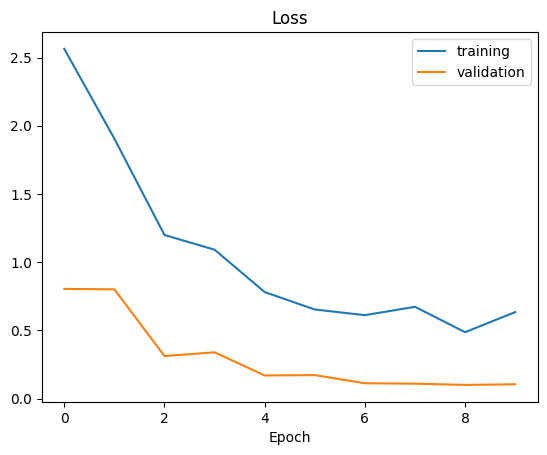

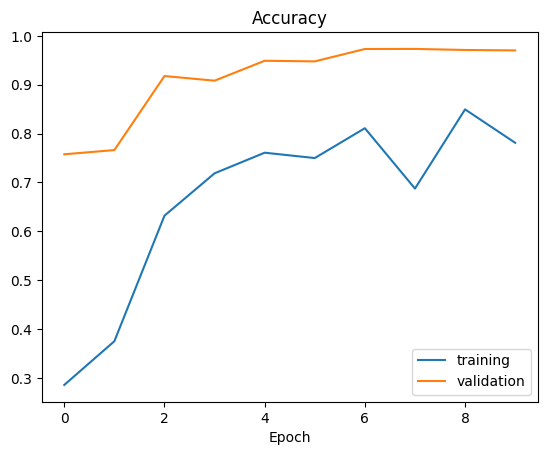

In [ ]:
plt.figure(1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['training', 'validation'])
plt.title('Loss')
plt.xlabel('Epoch')

plt.figure(2)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['training', 'validation'])
plt.title('Accuracy')
plt.xlabel('Epoch')

plt.show()

Model evaluation

In [ ]:
score = model.evaluate(X_test, y_test, verbose=0)
print('Test Score:', score[0])
print('Test Accuracy:', score[1])

Test Score: 0.10507122427225113
Test Accuracy: 0.9709770083427429


saving the the model locally

In [ ]:
model.save("/content/model.h5")
files.download("/content/model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>